# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: O código lê o arquivo CSV e usa os nomes dos genes para contar quantas letras cada um possui. Depois, ele verifica quantas vezes cada tamanho de nome aparece, criando uma frequência.
Em seguida, essa informação é adicionada à DataFrame para mostrar, em cada gene, a frequência relacionada ao seu número de caracteres. Por último, essa frequência é usada para gerar um gráfico de barras, facilitando a visualização dos resultados.

## 02 – Desenhe o fluxograma da resposta:

## 03 – Escreva o programa em Python:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataframel11e7.csv", index_col="Unnamed: 0")

df["num_caracteres"] = df.index.str.len()

frequencia = df["num_caracteres"].value_counts().sort_index()

df["frequencia_num_caracteres"] = df["num_caracteres"].map(frequencia)

print(df)
print(frequencia)

       num_caracteres dois_primeiros  qtd_a  tem_hu  frequencia_num_caracteres
ESR1                4             ES      0   False                          2
ESR2                4             ES      0   False                          2
PGR                 3             PG      0   False                          1
ERBB2               5             ER      0   False                          3
BRCA1               5             BR      1   False                          3
BRCA2               5             BR      1   False                          3
num_caracteres
3    1
4    2
5    3
Name: count, dtype: int64


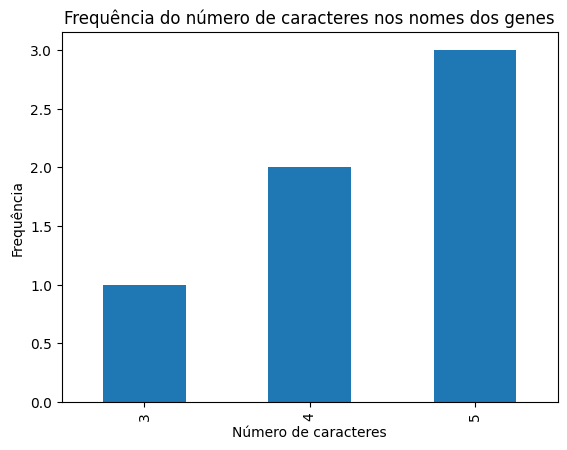

In [3]:
frequencia.plot(kind="bar")

plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequência do número de caracteres nos nomes dos genes")

plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: O código lê o CSV e organiza os dados em uma DataFrame. Depois, conta quantos caracteres existem no nome de cada gene e verifica quantas vezes cada tamanho aparece.

Como existe uma ordem entre os genes, o código cria uma coluna de ordem para manter essa sequência. Em seguida, adiciona a frequência na DataFrame e gera um gráfico de barras mostrando a frequência de cada grupo. 

## 05 – Desenhe o fluxograma da resposta:

## 06 – Escreva o programa em Python:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataframel11e7.csv", index_col="Unnamed: 0")

df["num_caracteres"] = df.index.str.len()

frequencia = df["num_caracteres"].value_counts().sort_index()

df_frequencia = frequencia.reset_index()
df_frequencia.columns = ["num_caracteres", "frequencia"]

df_frequencia["ordem"] = range(1, len(df_frequencia) + 1)

df = df.merge(
    df_frequencia,
    on="num_caracteres",
    how="left"
)

print(df)
print(df_frequencia)

   num_caracteres dois_primeiros  qtd_a  tem_hu  frequencia  ordem
0               4             ES      0   False           2      2
1               4             ES      0   False           2      2
2               3             PG      0   False           1      1
3               5             ER      0   False           3      3
4               5             BR      1   False           3      3
5               5             BR      1   False           3      3
   num_caracteres  frequencia  ordem
0               3           1      1
1               4           2      2
2               5           3      3


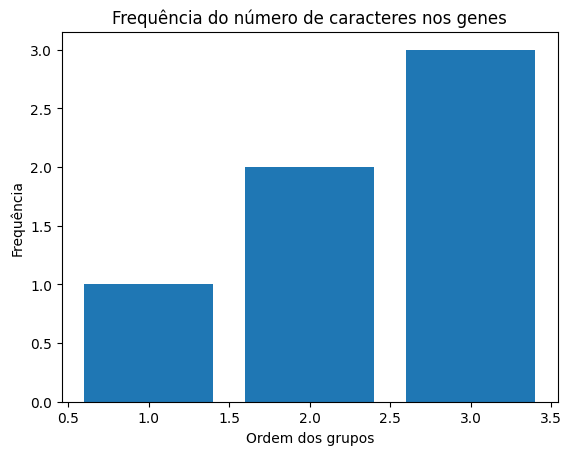

In [6]:
plt.bar(df_frequencia["ordem"], df_frequencia["frequencia"])
plt.xlabel("Ordem dos grupos")
plt.ylabel("Frequência")
plt.title("Frequência do número de caracteres nos genes")
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [7]:
import pandas as pd

df = df.drop(columns=["dois_primeiros", "qtd_a", "tem_hu"])

df.columns = ["num_caracteres", "frequencia", "ordem"]

df["amostra"] = "Amostra 1"

print(df)

   num_caracteres  frequencia  ordem    amostra
0               4           2      2  Amostra 1
1               4           2      2  Amostra 1
2               3           1      1  Amostra 1
3               5           3      3  Amostra 1
4               5           3      3  Amostra 1
5               5           3      3  Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [8]:
import numpy as np

amostra2 = np.random.randint(1, 10, 5)

frequencia_amostra2 = pd.Series(amostra2).value_counts().sort_index()

df_amostra2 = frequencia_amostra2.reset_index()
df_amostra2.columns = ["num_caracteres", "frequencia"]

df_amostra2["ordem"] = range(1, len(df_amostra2) + 1)
df_amostra2["amostra"] = "Amostra 2"

df = pd.concat([df, df_amostra2], ignore_index=True)

print(df)

   num_caracteres  frequencia  ordem    amostra
0               4           2      2  Amostra 1
1               4           2      2  Amostra 1
2               3           1      1  Amostra 1
3               5           3      3  Amostra 1
4               5           3      3  Amostra 1
5               5           3      3  Amostra 1
6               3           2      1  Amostra 2
7               7           1      2  Amostra 2
8               8           2      3  Amostra 2


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [9]:
import numpy as np
import pandas as pd

for n in range(3, 7):
    amostra = np.random.randint(1, 10, 5)

    frequencia = pd.Series(amostra).value_counts().sort_index()

    df_amostra = frequencia.reset_index()
    df_amostra.columns = ["num_caracteres", "frequencia"]

    df_amostra["ordem"] = range(1, len(df_amostra) + 1)
    df_amostra["amostra"] = f"Amostra {n}"

    df = pd.concat([df, df_amostra], ignore_index=True)

print(df)

    num_caracteres  frequencia  ordem    amostra
0                4           2      2  Amostra 1
1                4           2      2  Amostra 1
2                3           1      1  Amostra 1
3                5           3      3  Amostra 1
4                5           3      3  Amostra 1
5                5           3      3  Amostra 1
6                3           2      1  Amostra 2
7                7           1      2  Amostra 2
8                8           2      3  Amostra 2
9                4           1      1  Amostra 3
10               5           1      2  Amostra 3
11               6           1      3  Amostra 3
12               9           2      4  Amostra 3
13               4           1      1  Amostra 4
14               6           1      2  Amostra 4
15               7           1      3  Amostra 4
16               9           2      4  Amostra 4
17               1           1      1  Amostra 5
18               3           2      2  Amostra 5
19               4  

## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

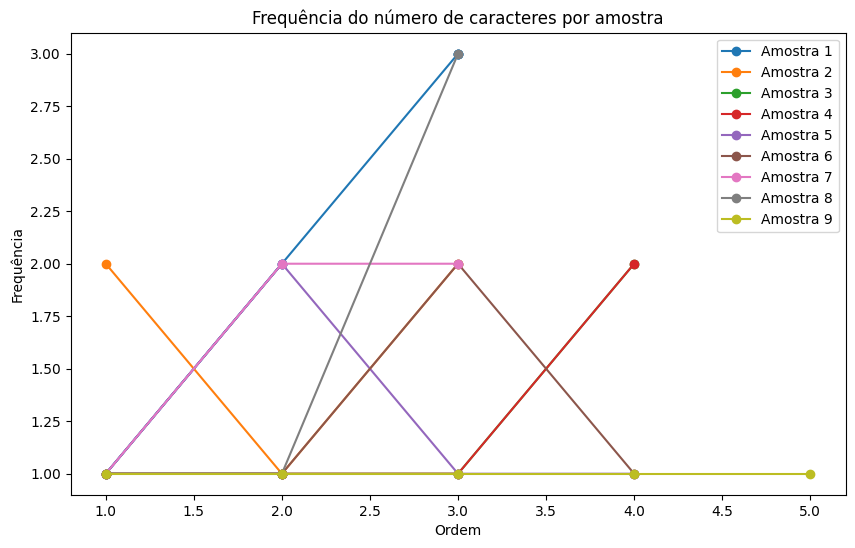

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for n in range(7, 10):
    amostra = np.random.randint(1, 10, 5)

    frequencia = pd.Series(amostra).value_counts().sort_index()

    df_amostra = frequencia.reset_index()
    df_amostra.columns = ["num_caracteres", "frequencia"]

    df_amostra["ordem"] = range(1, len(df_amostra) + 1)
    df_amostra["amostra"] = f"Amostra {n}"

    df = pd.concat([df, df_amostra], ignore_index=True)

plt.figure(figsize=(10, 6))

for amostra in df["amostra"].unique():
    dados = df[df["amostra"] == amostra]
    plt.plot(dados["ordem"], dados["frequencia"], marker="o", label=amostra)

plt.xlabel("Ordem")
plt.ylabel("Frequência")
plt.title("Frequência do número de caracteres por amostra")
plt.legend()
plt.show()